<a href="https://www.kaggle.com/code/rahadul231/heart-disease-prediction?scriptVersionId=311457067" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cardiovascular disease dataset
df = pd.read_csv(
    '/kaggle/input/datasets/sulianova/cardiovascular-disease-dataset/cardio_train.csv',sep=';')

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [3]:
#ap_hi - Systolic blood pressure 
#ap_lo - Diastolic blood pressure
#holesterol - Cholesterol level 
#gluc - Glucose level 
#smoke - Smoking status
#alco - Alcohol consumption
#active - Physical activity
#cardio - Presence of cardiovascular disease (target)

In [4]:
# Remove the 'id' column if it exists (Because it not useful for prediction)
df = df.drop(columns=['id'], errors='ignore')

# Verify the dataset
print(df.head())
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

     age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0  18393       2     168    62.0    110     80            1     1      0   
1  20228       1     156    85.0    140     90            3     1      0   
2  18857       1     165    64.0    130     70            3     1      0   
3  17623       2     169    82.0    150    100            1     1      0   
4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  
Dataset Shape: 70000 rows × 12 columns


In [5]:
from IPython.display import display

# Display the dataset in a tabular format
display(df)

# Show dataset dimensions
print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1



Dataset Shape: 70000 rows × 12 columns


In [6]:
# (0)-Absence or (1)-Presence of cardiovascular disease
df['cardio'].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

<Axes: xlabel='cardio', ylabel='count'>

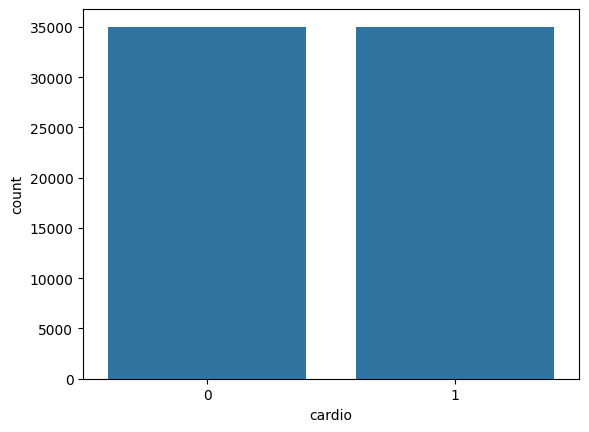

In [7]:
# Import the seaborn library for data visualization
import seaborn as sns  

# Create a count plot to visualize the distribution of the target variable 'cardio'
# This shows the number of patients with (1) and without (0) cardiovascular disease
sns.countplot(x='cardio', data=df)

In [8]:
# Before visualization, we need to check weather any null values are in the dataset.
# Let's Check it.
df.isnull().values.any()

np.False_

In [9]:
# Check in which column, Null value is abailable 
df.isna().sum()

age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

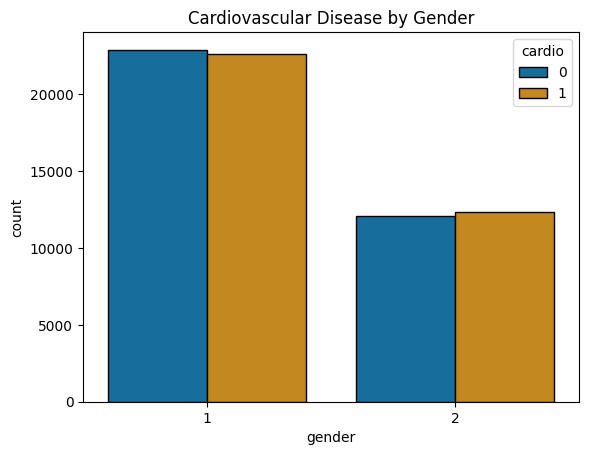

In [10]:
import seaborn as sns  # For plotting
import matplotlib.pyplot as plt  # To show the plot

# Cardiovascular disease (0/1) by gender
sns.countplot(x='gender', hue='cardio', data=df, palette='colorblind', edgecolor='black')
plt.title('Cardiovascular Disease by Gender')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


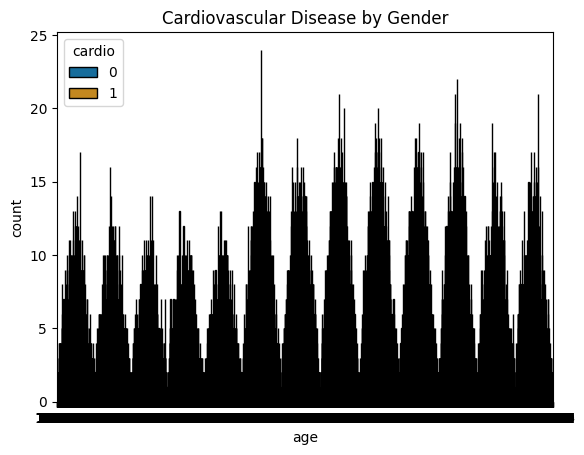

In [11]:
import seaborn as sns  # For plotting
import matplotlib.pyplot as plt  # To show the plot

# Cardiovascular disease (0/1) by gender
sns.countplot(x='age', hue='cardio', data=df, palette='colorblind', edgecolor='black')
plt.title('Cardiovascular Disease by Gender')
plt.show()


In [12]:
# Convert age from days to years as integers
df['age_years'] = (df['age'] / 365).round(0)

# Display the new column
df['age_years']

0        50.0
1        55.0
2        52.0
3        48.0
4        48.0
         ... 
69995    53.0
69996    62.0
69997    52.0
69998    61.0
69999    56.0
Name: age_years, Length: 70000, dtype: float64

In [13]:
# Create age groups to make the visualization clearer
df['age_group'] = pd.cut(df['age_years'],bins=[30, 40, 50, 60, 70, 80],
    labels=['30-39','40-49','50-59','60-69', '70-79'])

<Axes: xlabel='age_years', ylabel='count'>

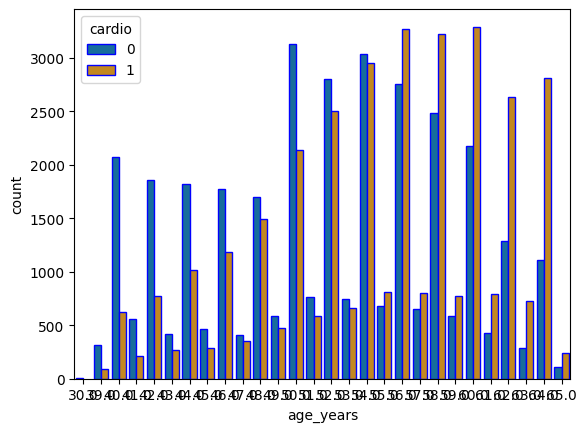

In [14]:
# (0)-Absence or (1)-Presence of cardiovascular disease by age
sns.countplot(x='age_years', hue='cardio', data=df, palette='colorblind', edgecolor='b')

In [15]:
# this descriptive statistics for all numerical columns in the DataFrame
# includes count, mean, standard deviation, minimum, quartiles (25%, 50%, 75%), and maximum values
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700,53.338686
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003,6.765294
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,30.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,65.000000


In [16]:
# Compute correlation matrix for numerical columns only
df.corr(numeric_only=True)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
age,1.000000,-0.022811,-0.081515,0.053684,0.020764,0.017647,0.154424,0.098703,-0.047633,-0.029723,-0.009927,0.238159,0.999090
gender,-0.022811,1.000000,0.499033,0.155406,0.006005,0.015254,-0.035821,-0.020491,0.338135,0.170966,0.005866,0.008109,-0.023017
height,-0.081515,0.499033,1.000000,0.290968,0.005488,0.006150,-0.050226,-0.018595,0.187989,0.094419,-0.006570,-0.010821,-0.081456
weight,0.053684,0.155406,0.290968,1.000000,0.030702,0.043710,0.141768,0.106857,0.067780,0.067113,-0.016867,0.181660,0.053661
ap_hi,0.020764,0.006005,0.005488,0.030702,1.000000,0.016086,0.023778,0.011841,-0.000922,0.001408,-0.000033,0.054475,0.020793
ap_lo,0.017647,0.015254,0.006150,0.043710,0.016086,1.000000,0.024019,0.010806,0.005186,0.010601,0.004780,0.065719,0.017754
cholesterol,0.154424,-0.035821,-0.050226,0.141768,0.023778,0.024019,1.000000,0.451578,0.010354,0.035760,0.009911,0.221147,0.154386
gluc,0.098703,-0.020491,-0.018595,0.106857,0.011841,0.010806,0.451578,1.000000,-0.004756,0.011246,-0.006770,0.089307,0.098596
smoke,-0.047633,0.338135,0.187989,0.067780,-0.000922,0.005186,0.010354,-0.004756,1.000000,0.340094,0.025858,-0.015486,-0.047884
alco,-0.029723,0.170966,0.094419,0.067113,0.001408,0.010601,0.035760,0.011246,0.340094,1.000000,0.025476,-0.007330,-0.029918


In [17]:
# Remove derived age-related columns if they exist
df = df.drop(columns=['age_years', 'age_group'], errors='ignore')

# Confirm removal
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  int64  
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 6.4 MB


In [18]:
# Compute correlation matrix for numerical columns only
df.corr(numeric_only=True)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
age,1.000000,-0.022811,-0.081515,0.053684,0.020764,0.017647,0.154424,0.098703,-0.047633,-0.029723,-0.009927,0.238159
gender,-0.022811,1.000000,0.499033,0.155406,0.006005,0.015254,-0.035821,-0.020491,0.338135,0.170966,0.005866,0.008109
height,-0.081515,0.499033,1.000000,0.290968,0.005488,0.006150,-0.050226,-0.018595,0.187989,0.094419,-0.006570,-0.010821
weight,0.053684,0.155406,0.290968,1.000000,0.030702,0.043710,0.141768,0.106857,0.067780,0.067113,-0.016867,0.181660
ap_hi,0.020764,0.006005,0.005488,0.030702,1.000000,0.016086,0.023778,0.011841,-0.000922,0.001408,-0.000033,0.054475
ap_lo,0.017647,0.015254,0.006150,0.043710,0.016086,1.000000,0.024019,0.010806,0.005186,0.010601,0.004780,0.065719
cholesterol,0.154424,-0.035821,-0.050226,0.141768,0.023778,0.024019,1.000000,0.451578,0.010354,0.035760,0.009911,0.221147
gluc,0.098703,-0.020491,-0.018595,0.106857,0.011841,0.010806,0.451578,1.000000,-0.004756,0.011246,-0.006770,0.089307
smoke,-0.047633,0.338135,0.187989,0.067780,-0.000922,0.005186,0.010354,-0.004756,1.000000,0.340094,0.025858,-0.015486
alco,-0.029723,0.170966,0.094419,0.067113,0.001408,0.010601,0.035760,0.011246,0.340094,1.000000,0.025476,-0.007330


/tmp/ipykernel_16/2396678411.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cardio_corr.index,y=cardio_corr.values,palette='viridis')


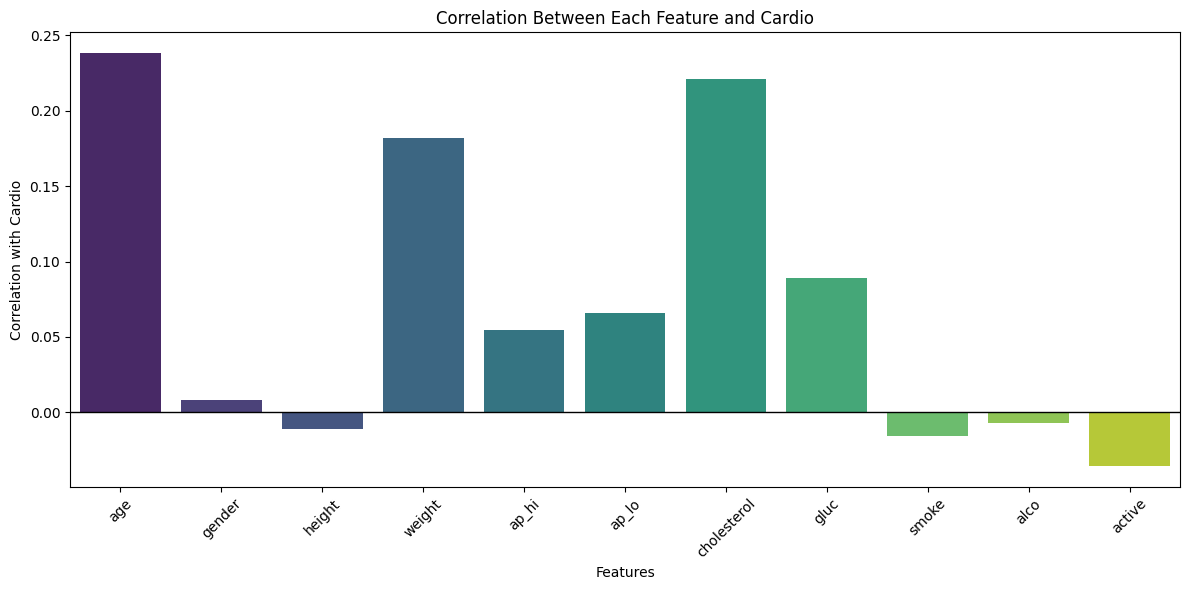

In [19]:
# Import libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation of each feature with target variable 'cardio'
cardio_corr = df.corr(numeric_only=True)['cardio'].drop('cardio')

# Create a figure
plt.figure(figsize=(12, 6))

# Plot correlation values
sns.barplot(x=cardio_corr.index,y=cardio_corr.values,palette='viridis')

# Add title and labels
plt.title('Correlation Between Each Feature and Cardio')
plt.xlabel('Features')
plt.ylabel('Correlation with Cardio')

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Draw a horizontal line at 0
plt.axhline(0, color='black', linewidth=1)

# Adjust layout
plt.tight_layout()

# Show the diagram
plt.show()

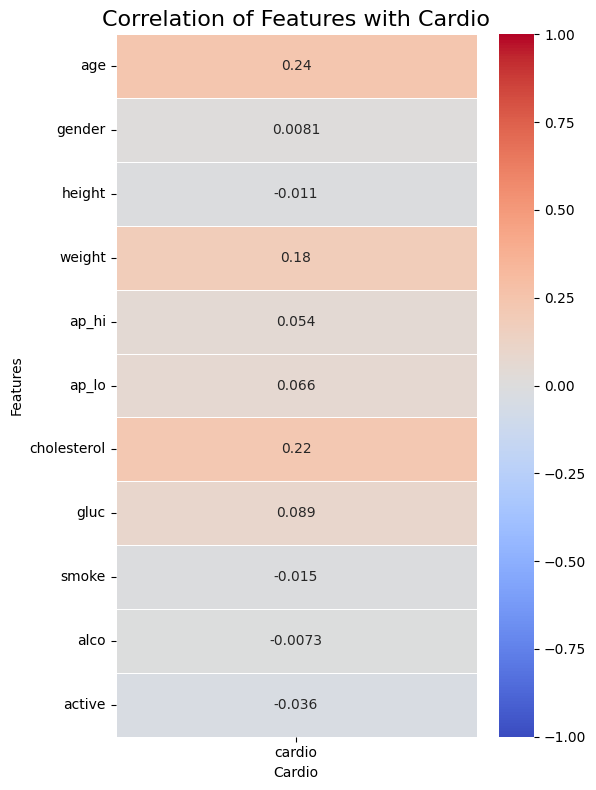

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlations with 'cardio'
cardio_corr = df.corr(numeric_only=True)[['cardio']].drop('cardio')

# Plot heatmap
plt.figure(figsize=(6, 8))
sns.heatmap(cardio_corr,annot=True,cmap='coolwarm',vmin=-1,vmax=1,linewidths=0.5)

plt.title('Correlation of Features with Cardio',fontsize=16)
plt.xlabel('Cardio')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [21]:
# Since correlation between age and cardio is the highest, so at first we will apply random forest on these. 
# After that we will apply on all the columns together.

In [22]:
# Select feature column age.
A = df.iloc[:, 10]

# Display the feature DataFrame
A

0        1
1        1
2        0
3        1
4        0
        ..
69995    1
69996    1
69997    0
69998    0
69999    1
Name: active, Length: 70000, dtype: int64

In [23]:
# Select the target variable (last column: 'cardio')
B = df.iloc[:, 11]

# Display the target variable
B

0        0
1        1
2        1
3        1
4        0
        ..
69995    0
69996    1
69997    1
69998    1
69999    0
Name: cardio, Length: 70000, dtype: int64

In [24]:
#Note: Now we are going to work on train-test split.

# Split data into training and testing sets
from sklearn.model_selection import train_test_split

In [25]:
# Define features and target
A=df.drop('cardio',axis=1)
B=df['cardio']

# Split the dataset
Atrain,Atest,Btrain,Btest = train_test_split(A,B,test_size=0.3,random_state=1)

# Display the training data
Atrain.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
23561,16136,2,169,71.0,100,80,1,1,1,0,1
34858,14615,1,158,69.0,140,80,2,1,0,0,1
54953,20507,1,164,65.0,120,80,1,1,0,0,1
59230,16720,1,153,53.0,100,60,1,1,0,0,1
1730,21050,1,159,71.0,140,90,1,1,0,0,1


In [26]:
# Show the number of rows and columns
print(f"{Atrain.shape[0]} rows × {Atrain.shape[1]} columns")

49000 rows × 11 columns


In [27]:
#Note: train-test split is done.
# Let's start applying Random Forest.

#Now import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

In [28]:
#Now create a object.
rfc = RandomForestClassifier()

In [29]:
# Lets fit the datas to train data.
rfc.fit(Atrain,Btrain)

RandomForestClassifier()

In [30]:
# Training is done. Now check model accuracy on the test dataset

# Accuracy is checking using this formula: Accuracy=(Number of Correct Predictions)/(Total Number of Predictions)
rfc.score(Atest,Btest)


0.7172857142857143

In [31]:
# Now, let's apply on all the columns together.

In [32]:
# Select all feature columns except the target column 'cardio'
X = df.iloc[:,:-1]

# Display the feature DataFrame
X

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
0,18393,2,168,62.0,110,80,1,1,0,0,1
1,20228,1,156,85.0,140,90,3,1,0,0,1
2,18857,1,165,64.0,130,70,3,1,0,0,0
3,17623,2,169,82.0,150,100,1,1,0,0,1
4,17474,1,156,56.0,100,60,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1
69996,22601,1,158,126.0,140,90,2,2,0,0,1
69997,19066,2,183,105.0,180,90,3,1,0,1,0
69998,22431,1,163,72.0,135,80,1,2,0,0,0


In [33]:
# Select the target variable (last column: 'cardio')
y = df.iloc[:, 11]

# Display the target variable
y

0        0
1        1
2        1
3        1
4        0
        ..
69995    0
69996    1
69997    1
69998    1
69999    0
Name: cardio, Length: 70000, dtype: int64

In [34]:
#Note: Now we are going to work on train-test split.

# Split data into training and testing sets
from sklearn.model_selection import train_test_split

In [35]:
# Define features and target
x=df.drop('cardio',axis=1)
y=df['cardio']

# Split the dataset
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.3,random_state=1)

# Display the training data
xtrain.head()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
23561,16136,2,169,71.0,100,80,1,1,1,0,1
34858,14615,1,158,69.0,140,80,2,1,0,0,1
54953,20507,1,164,65.0,120,80,1,1,0,0,1
59230,16720,1,153,53.0,100,60,1,1,0,0,1
1730,21050,1,159,71.0,140,90,1,1,0,0,1


In [36]:
# Show the number of rows and columns
print(f"{xtrain.shape[0]} rows × {xtrain.shape[1]} columns")

49000 rows × 11 columns


In [37]:
#Note: train-test split is done.
# Let's start applying Random Forest.

#Now import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

In [38]:
#Now create a object.
rfc = RandomForestClassifier()

In [39]:
# Lets fit the datas to train data.
rfc.fit(xtrain,ytrain)

RandomForestClassifier()

In [40]:
# Training is done. Now check model accuracy on the test dataset

# Accuracy is checking using this formula: Accuracy=(Number of Correct Predictions)/(Total Number of Predictions)
rfc.score(xtest,ytest)


0.7160952380952381

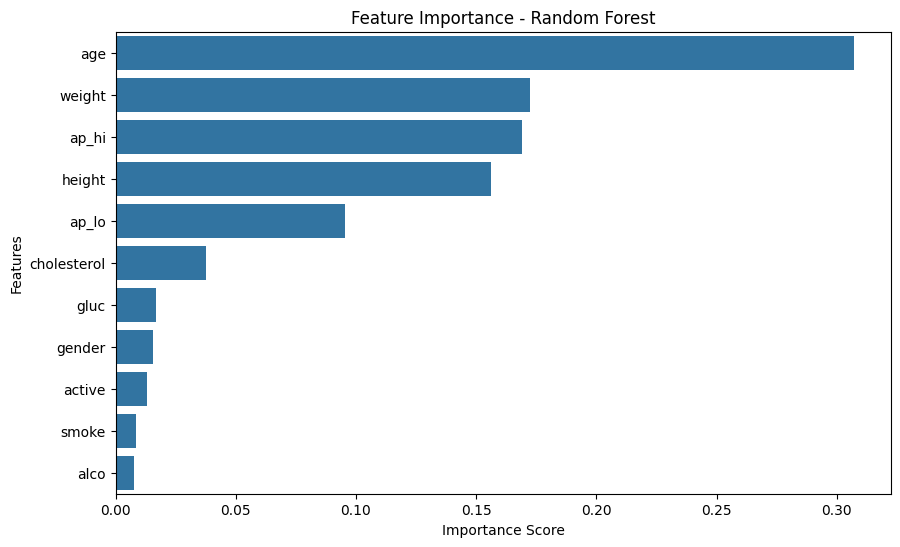

In [41]:
import pandas as pd
import seaborn as sns

# Compute feature importance
importance = pd.Series(rfc.feature_importances_, index=x.columns).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importance, y=importance.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [42]:
# Random_Forest(baseline) Model is done nd it's Typical Accuracy is 70% – 75%, 
# and Decision_Tree Model Typical Accuracy is 65% – 72%. These are common acccuracy range.

# So, let's try with Decision Tree Model.

In [43]:
# Select features and target
x = df.drop('cardio',axis=1)
y = df['cardio']

In [44]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.3,random_state=1)

In [45]:
#Now import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

In [46]:
#Now create a object.
dtc = DecisionTreeClassifier()

In [47]:
# Lets fit the datas to train data.
dtc.fit(xtrain,ytrain)

DecisionTreeClassifier()

In [48]:
# Training is done. Now check model accuracy on the test dataset

# Accuracy is checking using this formula: Accuracy=(TP+TN)/(TP+TN+FP+FN)
dtc.score(xtest,ytest)

0.6353809523809524

In [49]:
# Decision Tree Model is completed, 
# and Decision_Tree Model Typical Accuracy is 65% – 72%. These are common acccuracy range.

# Now, let's try with Logistic Regression Model and check the accuracy.

In [50]:
# Logistic Regression is a widely used classification algorithm.
# that is suitable for binary classification problems like predicting

# Now Let's work using Logistic Regression Classifier
# Import StandardScaler
from sklearn.preprocessing import StandardScaler
# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

In [51]:
# Create scaler object
scaler = StandardScaler()

# Scale training and testing data
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

In [52]:
# Create Logistic Regression model
lrc = LogisticRegression(solver='liblinear', max_iter=1000, random_state=1)

In [53]:
# Fit the model with scaled training data
lrc.fit(xtrain_scaled,ytrain)

LogisticRegression(max_iter=1000, random_state=1, solver='liblinear')

In [54]:
# Check accuracy on scaled test data
lrc.score(xtest_scaled,ytest)

0.7185238095238096

In [55]:
# Now let's compare 3 models predictions.

In [56]:
# Import pandas for creating comparison table
import pandas as pd

# Check accuracy of each model
rf_acc = rfc.score(xtest,ytest)
dt_acc = dtc.score(xtest,ytest)
lr_acc = lrc.score(xtest_scaled,ytest)

# Create a comparison table
model_comparison = pd.DataFrame({'Model':['Random Forest','Decision Tree','Logistic Regression'],'Accuracy':
    [rf_acc,dt_acc,lr_acc]})

# Show the comparison table
model_comparison

,Model,Accuracy
0,Random Forest,0.716095
1,Decision Tree,0.635381
2,Logistic Regression,0.718524


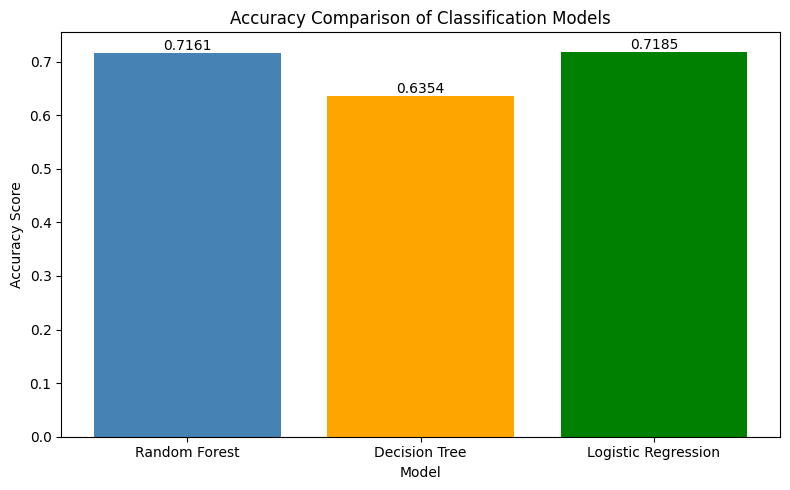

In [57]:
# Create bar chart for model comparison
plt.figure(figsize=(8, 5))
plt.bar(model_comparison['Model'],model_comparison['Accuracy'],color=['steelblue','orange','green'])

# Add title and labels
plt.title('Accuracy Comparison of Classification Models')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')

# Show accuracy values on bars
for i, value in enumerate(model_comparison['Accuracy']):plt.text(i, value + 0.005, f"{value:.4f}", ha='center')

# Show the figure
plt.tight_layout()
plt.show()